In [1]:
import pickle
import numpy as np
# import casadi as ca
from timeit import default_timer as timer
import matplotlib.pyplot as plt
from pyswarms.single.global_best import GlobalBestPSO

from util import *
from myGP_torch import *

import warnings
import logging
logging.disable(logging.CRITICAL)

#suppress warnings
warnings.filterwarnings('ignore')

# Try to use GP with deep kernel learning to better approximate the discontinuity

In [2]:
# Example usage with multi-output data
np.random.seed(0)

# Generate synthetic multi-output data
def fn(x):
    y1 = np.where(x < 1, np.sin(2*x), np.cos(x)) 
    y2 = np.where(x < 2, np.cos(2*x), np.sin(x)) 
    y = np.hstack([y1, y2])
    return y

X_train = np.linspace(0, 5, 100).reshape(-1, 1)
Y_train = fn(X_train)

# Convert to torch tensors
X_train = torch.from_numpy(X_train).float()
Y_train = torch.from_numpy(Y_train).float()

# Initialize model
training_params = {
    "max_iter": 1000,
    "optimizer": "Adam",
    "num_restarts": 5
}

### Using Matern32 kernel

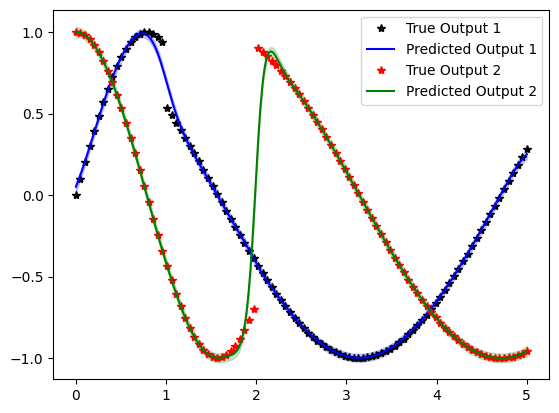

In [7]:
model = moGP_torch(X_train, Y_train, "Matern32", training_params=training_params)

X_test = torch.from_numpy(np.linspace(0, 5, 500).reshape(-1, 1)).float()
preds = model.predict(X_test)
mean = preds[0]
var = preds[1]

# Visualize the predictions
import matplotlib.pyplot as plt

plt.plot(X_train.numpy(), Y_train.numpy()[:, 0], 'k*', label="True Output 1")
plt.plot(X_test.numpy(), mean[:, 0], 'b', label="Predicted Output 1")
plt.fill_between(X_test.numpy().flatten(), 
                (mean[:, 0] - 2 * var[:, 0]), 
                (mean[:, 0] + 2 * var[:, 0]), alpha=0.2, color='blue')

plt.plot(X_train.numpy(), Y_train.numpy()[:, 1], 'r*', label="True Output 2")
plt.plot(X_test.numpy(), mean[:, 1], 'g', label="Predicted Output 2")
plt.fill_between(X_test.numpy().flatten(), 
                 (mean[:, 1] - 2 * var[:, 1]), 
                 (mean[:, 1] + 2 * var[:, 1]), alpha=0.2, color='green')

plt.legend()
plt.show()

### Using deep learning kernel

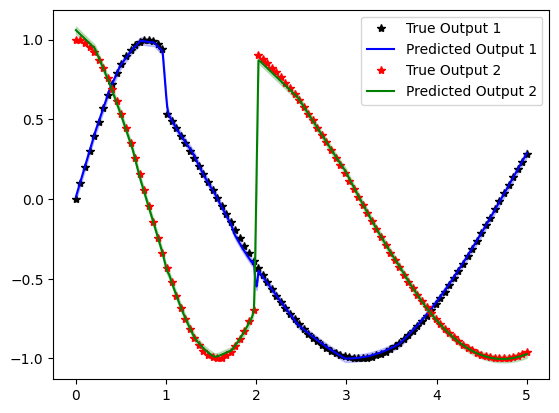

In [8]:
model = moGP_torch(X_train, Y_train, "DLK", training_params=training_params)

X_test = torch.from_numpy(np.linspace(0, 5, 500).reshape(-1, 1)).float()
preds = model.predict(X_test)
mean = preds[0]
var = preds[1]

# Visualize the predictions
import matplotlib.pyplot as plt

plt.plot(X_train.numpy(), Y_train.numpy()[:, 0], 'k*', label="True Output 1")
plt.plot(X_test.numpy(), mean[:, 0], 'b', label="Predicted Output 1")
plt.fill_between(X_test.numpy().flatten(), 
                (mean[:, 0] - 2 * var[:, 0]), 
                (mean[:, 0] + 2 * var[:, 0]), alpha=0.2, color='blue')

plt.plot(X_train.numpy(), Y_train.numpy()[:, 1], 'r*', label="True Output 2")
plt.plot(X_test.numpy(), mean[:, 1], 'g', label="Predicted Output 2")
plt.fill_between(X_test.numpy().flatten(), 
                 (mean[:, 1] - 2 * var[:, 1]), 
                 (mean[:, 1] + 2 * var[:, 1]), alpha=0.2, color='green')

plt.legend()
plt.show()